Nama: Alfin Oktavian

NIM: 240401010282

Kelas: IF-403

=== Shape Dataset ===
(891, 8)

=== Tipe Data ===
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object

=== Missing Values ===
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

=== Distribusi Target (survived) ===
survived
0    549
1    342
Name: count, dtype: int64

=== Distribusi Target (%) ===
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


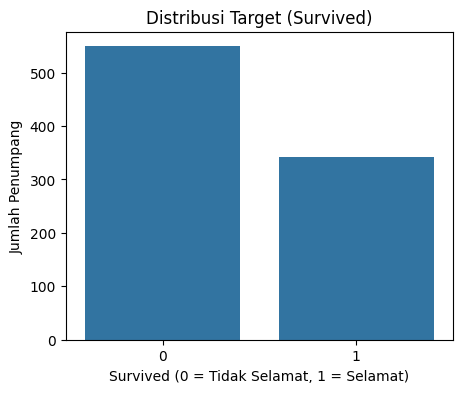

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Muat dataset Titanic
df = sns.load_dataset('titanic')

# Pilih kolom yang akan digunakan
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df = df[cols].copy()

# Ukuran dataset
print("=== Shape Dataset ===")
print(df.shape)

# Tipe data
print("\n=== Tipe Data ===")
print(df.dtypes)

# Missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Distribusi target
print("\n=== Distribusi Target (survived) ===")
print(df['survived'].value_counts())

print("\n=== Distribusi Target (%) ===")
print(df['survived'].value_counts(normalize=True).round(3))

# Visualisasi distribusi target
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='survived')
plt.title('Distribusi Target (Survived)')
plt.xlabel('Survived (0 = Tidak Selamat, 1 = Selamat)')
plt.ylabel('Jumlah Penumpang')
plt.show()

In [ ]:
# Age: isi dengan median (robust terhadap outlier)
df['age'] = df['age'].fillna(df['age'].median())

# Embarked: isi dengan modus (nilai yang paling sering muncul)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Cek kembali missing values
print("Missing setelah handling:")
print(df.isnull().sum())

Missing setelah handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [ ]:
# One-Hot Encoding untuk 'sex' dan 'embarked'
df = pd.get_dummies(
    df,
    columns=['sex', 'embarked'],
    drop_first=True,  # hindari dummy variable trap
    dtype=int
)

print("Kolom setelah encoding:")
print(df.columns.tolist())

Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # proporsi kelas terjaga
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')

print('\nProporsi survived di Train:')
print(y_train.value_counts(normalize=True).round(3))

print('\nProporsi survived di Test:')
print(y_test.value_counts(normalize=True).round(3))

Train: 712 baris
Test : 179 baris

Proporsi survived di Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Hanya kolom numerik yang perlu di-scale
# Kolom biner hasil One-Hot Encoding tidak perlu di-scale
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']

scaler = StandardScaler()

# Fit dan transform data training
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Transform data testing menggunakan parameter dari training
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Mean scaler (dari train):', scaler.mean_.round(2))
print('Std scaler (dari train):', scaler.scale_.round(2))

print()
print('Contoh X_train setelah scaling:')
print(X_train.head(3).round(3))

print('\nData siap dilatih model Machine Learning!')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')

Mean scaler (dari train): [ 2.31 29.46  0.49  0.39 31.82]
Std scaler (dari train): [ 0.83 13.03  1.06  0.84 48.03]

Contoh X_train setelah scaling:
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1

Data siap dilatih model Machine Learning!
X_train: (712, 8), y_train: (712,)
X_test : (179, 8), y_test : (179,)


Kesimpulan singkat:

Pada Pertemuan ke 6 kali ini, saya mempelajari tahapan persiapan data sebelum digunakan dalam proses Machine Learning.

Saya belajar menangani missing value, mengubah data kategorikal menjadi numerik menggunakan one-hot encoding, membagi dataset menjadi data training dan testing.

Dari praktikum ini saya memahami bahwa kualitas dan kesiapan data sangat berpengaruh terhadap performa model Machine Learning.

Proses preprocessing membantu memastikan data berada dalam format yang sesuai sehingga model dapat dilatih dan dievaluasi dengan lebih baik pada tahap selanjutnya.